# 第 8 章 · TransE 与 Attention 代码实验

本页把“关系”和“注意力”都变成可计算表格。TransE 部分看向量平移是否把国家指向首都；Attention 部分看一个词主要关注句子里的哪些词。

[章节网页](../ch8.html)

## 运行内容

- 计算国家-首都 TransE 距离
- 计算 Transformer attention 权重
- 绘制几何图和热力图

## 0. 环境与数据

先载入表格、向量和画图工具。后续两部分彼此独立，可以分开运行和阅读。

In [1]:
# 载入本页会用到的数据集、模型和绘图工具。
import importlib.util
import logging
import math
import subprocess
import sys
import warnings
from collections import Counter, defaultdict
from pathlib import Path

required_packages = {
    "numpy": "numpy>=1.24",
    "pandas": "pandas>=2.0",
    "matplotlib": "matplotlib>=3.7",
    "scipy": "scipy>=1.10",
    "sklearn": "scikit-learn>=1.3",
}
missing = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from PIL import Image
from IPython.display import display
from scipy.optimize import dual_annealing
from scipy.signal import correlate2d
from sklearn.datasets import load_digits, load_iris, load_sample_image, make_moons
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import accuracy_score, confusion_matrix, log_loss, mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.svm import SVC

font_paths = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc",
    "/System/Library/Fonts/Supplemental/Arial Unicode.ttf",
    "/Library/Fonts/Arial Unicode.ttf",
    "/System/Library/Fonts/STHeiti Medium.ttc",
    "/System/Library/Fonts/STHeiti Light.ttc",
]
font_name = "DejaVu Sans"
for path in font_paths:
    if Path(path).exists():
        fm.fontManager.addfont(path)
        font_name = fm.FontProperties(fname=path).get_name()
        break

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.unicode_minus": False,
    "font.family": "sans-serif",
    "font.sans-serif": [font_name, "DejaVu Sans", "sans-serif"],
})

## 1. 关系向量

正确三元组的距离应该更小，替换实体后的距离应该变大。几何图帮助读者看到 h + r 是否靠近 t。

In [2]:
# TransE：用国家-首都关系比较正确三元组和替换实体后的距离。
entity_vec = {
    "France": np.array([0.10, 0.82]),
    "Paris": np.array([0.72, 0.60]),
    "Germany": np.array([0.05, 0.22]),
    "Berlin": np.array([0.68, 0.01]),
    "Italy": np.array([0.18, 0.48]),
    "Rome": np.array([0.80, 0.28]),
}
relation_vec = {"capital_of": np.array([0.62, -0.22])}

triples = [
    ("France", "capital_of", "Paris", "正例"),
    ("Germany", "capital_of", "Berlin", "正例"),
    ("Italy", "capital_of", "Rome", "正例"),
    ("France", "capital_of", "Berlin", "替换尾实体"),
    ("Germany", "capital_of", "Paris", "替换尾实体"),
]

rows = []
for head, relation, tail, kind in triples:
    score_vec = entity_vec[head] + relation_vec[relation] - entity_vec[tail]
    rows.append({
        "样本": kind,
        "三元组": f"({head}, {relation}, {tail})",
        "距离": round(float(np.linalg.norm(score_vec)), 3),
    })

transe_df = pd.DataFrame(rows).sort_values("距离")
display(transe_df)

,样本,三元组,距离
0,正例,"(France, capital_of, Paris)",0.000
1,正例,"(Germany, capital_of, Berlin)",0.014
2,正例,"(Italy, capital_of, Rome)",0.020
3,替换尾实体,"(France, capital_of, Berlin)",0.591
4,替换尾实体,"(Germany, capital_of, Paris)",0.602


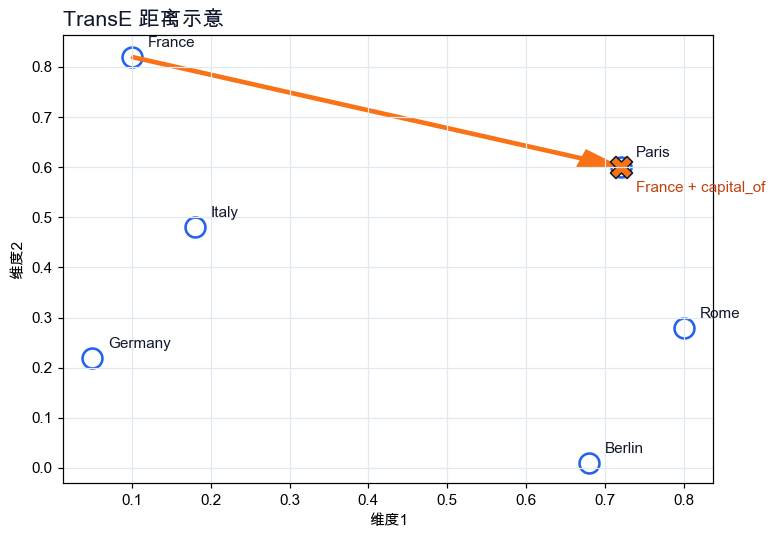

In [3]:
# 绘制 h + r 与候选 t 的几何距离。
fig, ax = plt.subplots(figsize=(7.2, 5.0))
h = entity_vec["France"]
r = relation_vec["capital_of"]
target_point = h + r

for name, vec in entity_vec.items():
    ax.scatter(vec[0], vec[1], s=170, color="#ffffff", edgecolor="#2563eb", linewidth=1.7)
    ax.text(vec[0] + 0.02, vec[1] + 0.02, name, color="#0f172a")

ax.arrow(h[0], h[1], r[0], r[1], width=0.006, head_width=0.035, color="#f97316", length_includes_head=True)
ax.scatter(target_point[0], target_point[1], s=210, marker="X", color="#f97316", edgecolor="#0f172a", linewidth=1.0)
ax.text(target_point[0] + 0.02, target_point[1] - 0.05, "France + capital_of", color="#c2410c")
ax.set_title("TransE 距离示意", loc="left", fontsize=14, fontweight="bold", color="#0f172a")
ax.set_xlabel("维度1")
ax.set_ylabel("维度2")
ax.grid(True, color="#e2e8f0", linewidth=0.8)
plt.tight_layout()
plt.show()

## 2. 注意力权重

热力图的每一行代表一个正在读的词，每一列代表它可以关注的词。颜色越深、数值越大，说明关注越强。

In [4]:
# 用一组可解释的 query/key 特征，让同一句话的 attention 更容易读。
tokens = ["the", "cat", "sat", "on", "the", "mat"]
labels = ["the(1)", "cat", "sat", "on", "the(2)", "mat"]
features = ["subject_noun", "verb", "prep", "place_noun", "det"]

K = pd.DataFrame([
    [0, 0, 0, 0, 1],  # the(1): determiner
    [1, 0, 0, 0, 0],  # cat: subject noun
    [0, 1, 0, 0, 0],  # sat: verb
    [0, 0, 1, 0, 0],  # on: preposition
    [0, 0, 0, 0, 1],  # the(2): determiner
    [0, 0, 0, 1, 0],  # mat: place noun
], index=labels, columns=features)

Q = pd.DataFrame([
    [8.0, 0.0, 0.0, 0.0, 0.0],  # the(1) looks for the noun it modifies: cat
    [0.0, 8.0, 0.0, 0.0, 0.0],  # cat looks for the action: sat
    [6.5, 0.0, 0.0, 6.5, 0.0],  # sat looks at the subject and the location
    [0.0, 0.0, 0.0, 8.0, 0.0],  # on points to its object: mat
    [0.0, 0.0, 0.0, 8.0, 0.0],  # the(2) modifies mat
    [0.0, 0.0, 8.0, 0.0, 0.0],  # mat looks back to the preposition: on
], index=labels, columns=features)

V = np.array([
    [0.20, 0.10],
    [0.85, 0.20],
    [0.45, 0.80],
    [0.20, 0.65],
    [0.20, 0.10],
    [0.70, 0.55],
])

scores = Q.to_numpy() @ K.to_numpy().T / math.sqrt(len(features))
weights = np.exp(scores - scores.max(axis=1, keepdims=True))
weights = weights / weights.sum(axis=1, keepdims=True)
attn_output = weights @ V

weight_df = pd.DataFrame(np.round(weights, 3), index=labels, columns=labels)
focus_rows = []
for i, label in enumerate(labels):
    kept = [j for j in range(len(labels)) if weights[i, j] >= 0.20]
    focus_rows.append({
        "当前词": label,
        "主要关注": ", ".join(labels[j] for j in kept),
        "权重": ", ".join(f"{weights[i, j]:.2f}" for j in kept),
    })

display(pd.DataFrame(focus_rows))
display(weight_df)
display(pd.DataFrame(np.round(attn_output, 3), index=labels, columns=["输出1", "输出2"]))

,当前词,主要关注,权重
0,the(1),cat,0.88
1,cat,sat,0.88
2,sat,"cat, mat","0.45, 0.45"
3,on,mat,0.88
4,the(2),mat,0.88
5,mat,on,0.88


,the(1),cat,sat,on,the(2),mat
the(1),0.025,0.877,0.025,0.025,0.025,0.025
cat,0.025,0.025,0.877,0.025,0.025,0.025
sat,0.025,0.451,0.025,0.025,0.025,0.451
on,0.025,0.025,0.025,0.025,0.025,0.877
the(2),0.025,0.025,0.025,0.025,0.025,0.877
mat,0.025,0.025,0.025,0.877,0.025,0.025


,输出1,输出2
the(1),0.789,0.229
cat,0.448,0.741
sat,0.725,0.379
on,0.661,0.528
the(2),0.661,0.528
mat,0.234,0.613


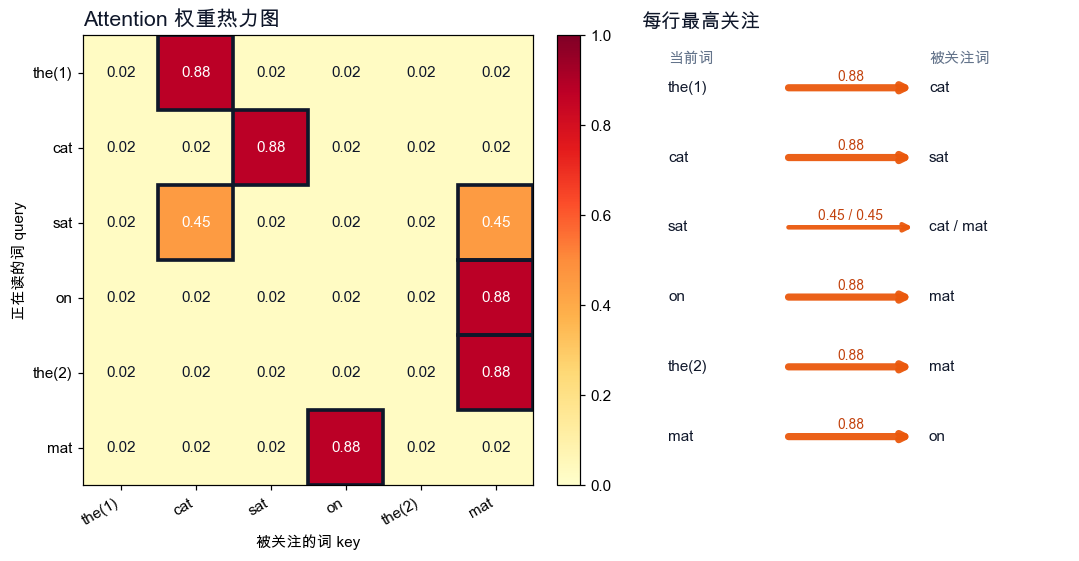

In [5]:
# 画出权重热力图，并把每一行的最高权重直接标出来。
fig, (ax, link_ax) = plt.subplots(
    1,
    2,
    figsize=(10.8, 5.2),
    gridspec_kw={"width_ratios": [1.25, 0.9]},
)
im = ax.imshow(weights, cmap="YlOrRd", vmin=0, vmax=1)
ax.set_xticks(range(len(labels)), labels, rotation=30, ha="right")
ax.set_yticks(range(len(labels)), labels)
ax.set_xlabel("被关注的词 key")
ax.set_ylabel("正在读的词 query")

for i in range(len(labels)):
    max_weight = weights[i].max()
    for j in range(len(labels)):
        value = weights[i, j]
        color = "#ffffff" if value > 0.45 else "#0f172a"
        weight = "bold" if value == max_weight else "normal"
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", color=color, fontweight=weight)
        if value == max_weight:
            ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False, edgecolor="#0f172a", linewidth=2.4))

ax.set_title("Attention 权重热力图", loc="left", fontsize=14, fontweight="bold", color="#0f172a")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

link_ax.set_xlim(0, 1)
link_ax.set_ylim(-0.7, len(labels) - 0.25)
link_ax.axis("off")
link_ax.text(0.02, len(labels) - 0.15, "每行最高关注", fontsize=13, fontweight="bold", color="#0f172a")
link_ax.text(0.08, len(labels) - 0.65, "当前词", color="#64748b", fontweight="bold")
link_ax.text(0.68, len(labels) - 0.65, "被关注词", color="#64748b", fontweight="bold")

for i in range(len(tokens)):
    y = len(labels) - 1 - i
    max_weight = weights[i].max()
    top_indices = [j for j in range(len(labels)) if np.isclose(weights[i, j], max_weight)]
    target_text = " / ".join(labels[j] for j in top_indices)
    value_text = " / ".join(f"{weights[i, j]:.2f}" for j in top_indices)
    link_ax.text(0.08, y, labels[i], ha="left", va="center", color="#0f172a")
    link_ax.text(0.68, y, target_text, ha="left", va="center", color="#0f172a", fontweight="bold")
    link_ax.annotate(
        "",
        xy=(0.65, y),
        xytext=(0.35, y),
        arrowprops={"arrowstyle": "->", "lw": 1.2 + 4.0 * max_weight, "color": "#ea580c", "alpha": 0.95},
    )
    link_ax.text(0.50, y + 0.16, value_text, ha="center", va="center", color="#c2410c", fontsize=9)

plt.tight_layout()
plt.show()